# Violent Crime Capstone

This notebook:
- Removes counties under 10,000 and those without FBI data
- Reruns EDA with new dataset
- Looks at data by County
- Bins poverty, eduction, unemployment based on quartile as low, medium-low, medium-high, and high
- Save data set as "capstone_data_with_crime_rate.csv"

# 1. Import and Remove County Outliers

In [53]:
import pandas as pd

df = pd.read_csv("capstone_data_20260414_Wendy.csv")
df.head()

,state,metropolitan_nonmetropolitan,county,violent_crime_count,murder_and_nonnegligent_manslaughter_count,rape_count,robbery_count,aggravated_assault_count,property_crime,burglary,...,unemployment_pct,median_income,poverty_pct,bachelors_or_higher_pct,population,violent_crime_rate_per_100k,murder_and_nonnegligent_manslaughter_rate,rape_rate,robbery_rate,aggravated_assault_rate
0,ALABAMA,Metropolitan County,Autauga,54,1,7,0,46,221,46,...,2.7,72481.0,11.3,29.1,59947,90.079570,1.668140,11.676981,0.000000,76.734449
1,ALABAMA,Metropolitan County,Baldwin,137,0,4,0,133,170,23,...,2.7,78775.0,10.1,33.7,246989,55.468057,0.000000,1.619505,0.000000,53.848552
2,ALABAMA,Metropolitan County,Bibb,34,0,5,0,29,78,26,...,3.0,52541.0,22.5,11.7,22130,153.637596,0.000000,22.593764,0.000000,131.043832
3,ALABAMA,Metropolitan County,Blount,82,1,18,2,61,298,66,...,2.7,64190.0,12.9,15.8,59518,137.773447,1.680164,30.242952,3.360328,102.490003
4,ALABAMA,Metropolitan County,Calhoun,238,2,5,0,231,192,48,...,3.2,55029.0,17.9,20.6,116090,205.013352,1.722801,4.307003,0.000000,198.983547


In [54]:
df["county_state"] = df["county"] + ", " + df["state"]

In [55]:
# removes counties that did not report crime data
# removes counties that are small than 10,000
# gets rid of noise but does not bias the results toward urban areas
df_valid = df[
    (df["violent_crime_count"] > 0) &
    (df["population"] > 10000)
]

In [56]:
label_map = {
    "violent_crime_count": "Violent Crime Count",
    "murder_and_nonnegligent_manslaughter_count": "Murder (Nonnegligent Manslaughter) Count",
    "rape_count": "Rape Count",
    "robbery_count": "Robbery Count",
    "aggravated_assault_count": "Aggravated Assault Count",

    "violent_crime_rate_per_100k": "Violent Crime Rate (per 100,000)",
    "murder_and_nonnegligent_manslaughter_rate": "Murder (Nonnegligent Manslaughter) Rate",
    "rape_rate": "Rape Rate",
    "robbery_rate": "Robbery Rate",
    "aggravated_assault_rate": "Aggravated Assault Rate",

    "unemployment_pct": "Unemployment Rate (%)",
    "poverty_pct": "Poverty Rate (%)",
    "bachelors_or_higher_pct": "Bachelor's Degree (%)",

    "median_income": "Median Household Income",

    "county": "County",
    "state": "State", 
    "county_state": "County, State"
}

## 2. Reruns EDA with New Dataset

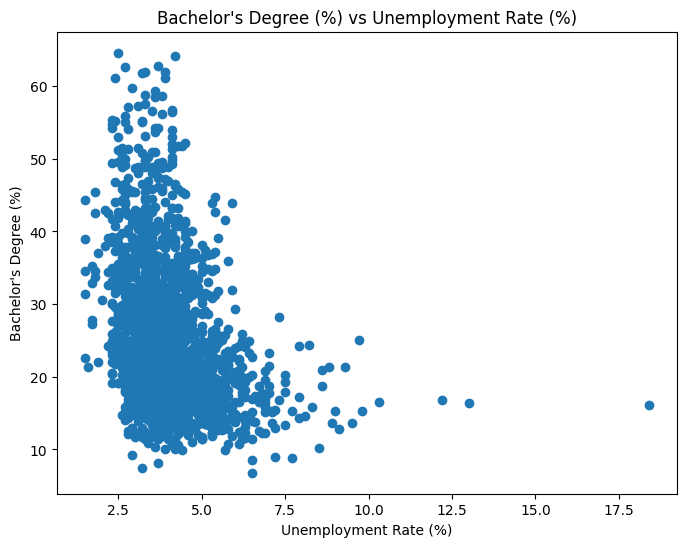

In [57]:
import matplotlib.pyplot as plt

x = "unemployment_pct"
y = "bachelors_or_higher_pct"

plt.figure(figsize=(8, 6))

plt.scatter(df_valid[x], df_valid[y])

plt.xlabel(label_map[x])
plt.ylabel(label_map[y])

plt.title(f"{label_map[y]} vs {label_map[x]}")

plt.show()

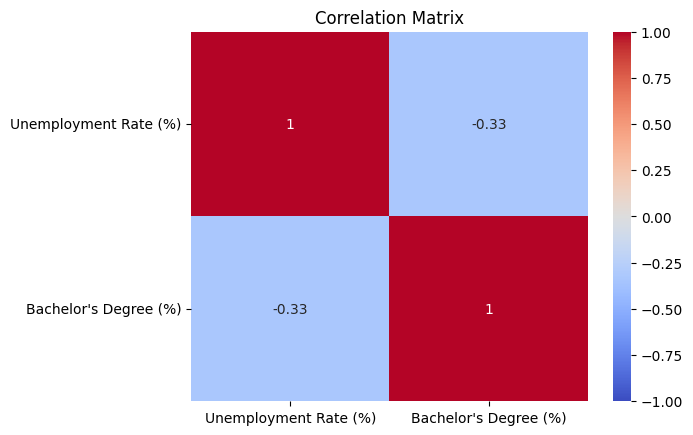

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# correlation
corr = df_valid[["unemployment_pct", "bachelors_or_higher_pct"]].corr()

# rename for display using label_map
corr_plot = corr.rename(index=label_map, columns=label_map)

# plot
sns.heatmap(
    corr_plot,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()

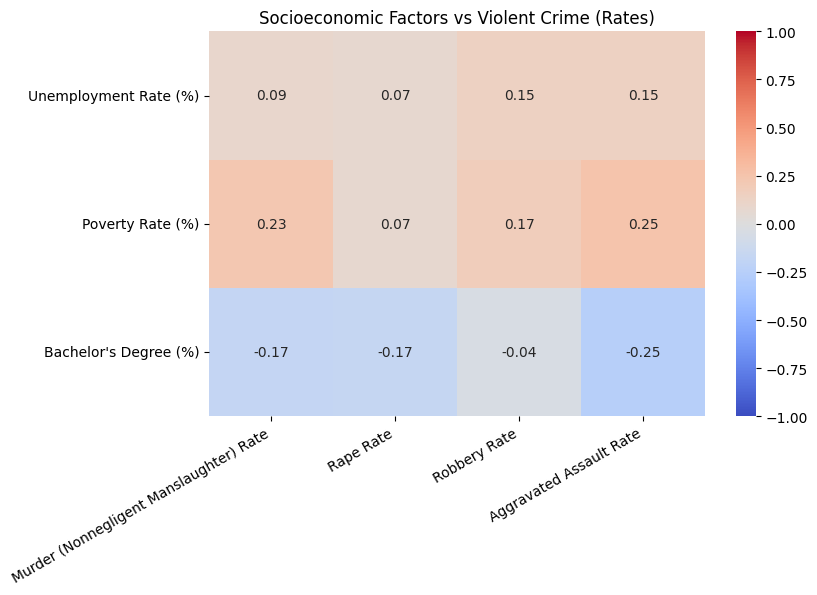

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

predictors = [
    "unemployment_pct",
    "poverty_pct",
    "bachelors_or_higher_pct"
]

crime_rates = [
    "murder_and_nonnegligent_manslaughter_rate",
    "rape_rate",
    "robbery_rate",
    "aggravated_assault_rate"
]

# correlation matrix
corr = df_valid[predictors + crime_rates].corr()
subset = corr.loc[predictors, crime_rates]

subset_plot = subset.rename(index=label_map, columns=label_map)

plt.figure(figsize=(8,5))

sns.heatmap(
    subset_plot,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.title("Socioeconomic Factors vs Violent Crime (Rates)")

plt.show()

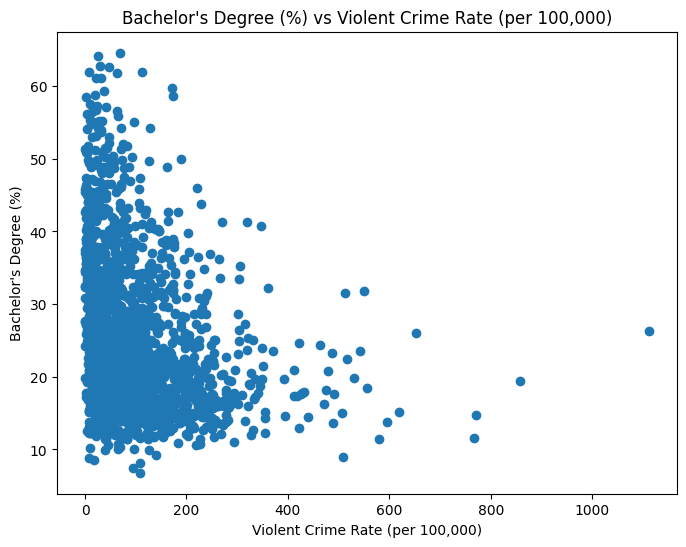

In [60]:
import matplotlib.pyplot as plt

x = "violent_crime_rate_per_100k"
y = "bachelors_or_higher_pct"

plt.figure(figsize=(8, 6))

plt.scatter(df_valid[x], df_valid[y])

plt.xlabel(label_map[x])
plt.ylabel(label_map[y])

plt.title(f"{label_map[y]} vs {label_map[x]}")

plt.show()

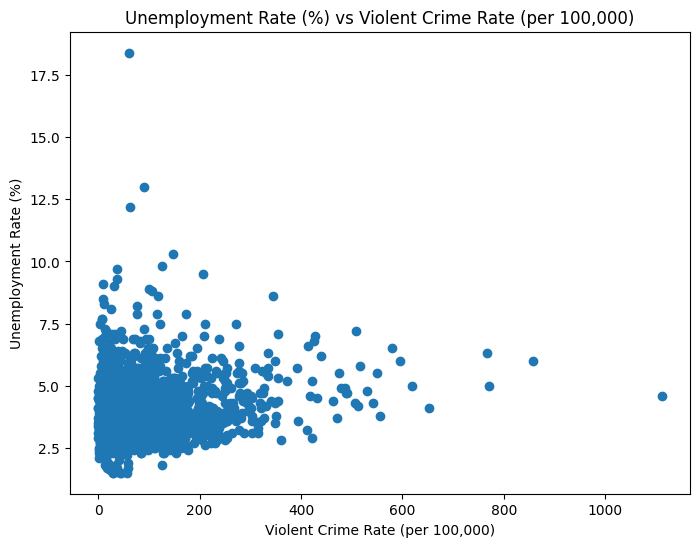

In [61]:
import matplotlib.pyplot as plt

x = "violent_crime_rate_per_100k"
y = "unemployment_pct"

plt.figure(figsize=(8, 6))

plt.scatter(df_valid[x], df_valid[y])

plt.xlabel(label_map[x])
plt.ylabel(label_map[y])

plt.title(f"{label_map[y]} vs {label_map[x]}")

plt.show()

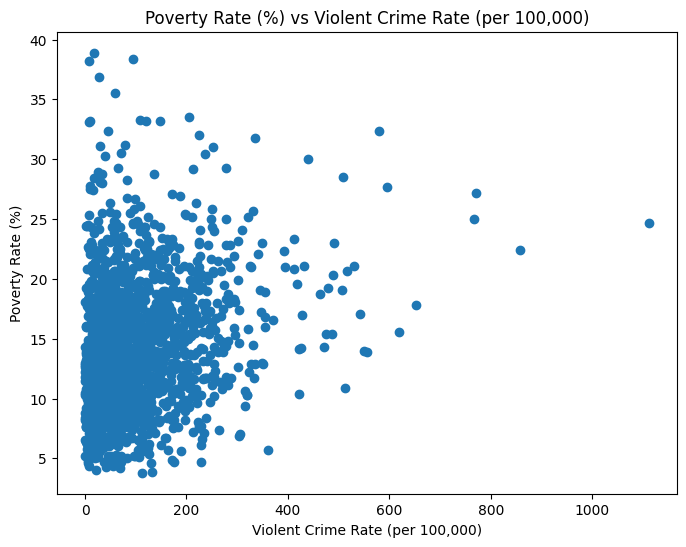

In [62]:
import matplotlib.pyplot as plt

x = "violent_crime_rate_per_100k"
y = "poverty_pct"

plt.figure(figsize=(8, 6))

plt.scatter(df_valid[x], df_valid[y])

plt.xlabel(label_map[x])
plt.ylabel(label_map[y])

plt.title(f"{label_map[y]} vs {label_map[x]}")

plt.show()

In [63]:
df["fips"] = df["fips"].astype(str).str.zfill(5)

## 3. Looks at the Data by County

In [64]:
import plotly.express as px

fig = px.choropleth(
    df_valid,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations="fips",
    color="violent_crime_rate_per_100k",
    color_continuous_scale="Reds",
    range_color=(0, 500),
    scope="usa",
    hover_name="county",
    hover_data={
        "state": True,
        "violent_crime_rate_per_100k": ":.2f",
        "fips": False
    },
    labels={"violent_crime_rate_per_100k": "Violent Crime Rate (per 100,000)"},
    title="Violent Crime Rate by County"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(margin={"r":0, "t":50, "l":0, "b":0})

fig.show()


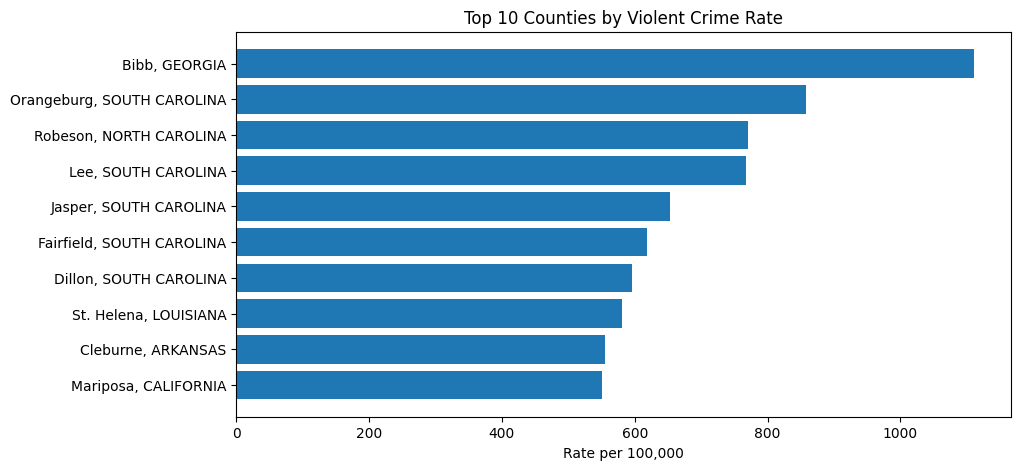

In [65]:
top10 = df_valid.nlargest(10, "violent_crime_rate_per_100k")

plt.figure(figsize=(10,5))
plt.barh(top10["county_state"], top10["violent_crime_rate_per_100k"])
plt.gca().invert_yaxis()
plt.title("Top 10 Counties by Violent Crime Rate")
plt.xlabel("Rate per 100,000")
plt.show()

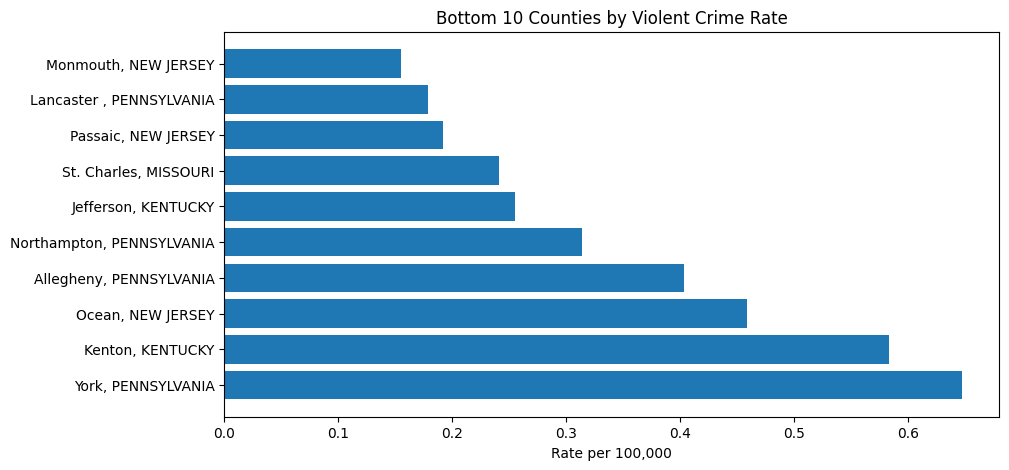

In [66]:
bottom10 = df_valid.nsmallest(10, "violent_crime_rate_per_100k")

plt.figure(figsize=(10,5))
plt.barh(bottom10["county_state"], bottom10["violent_crime_rate_per_100k"])
plt.gca().invert_yaxis()
plt.title("Bottom 10 Counties by Violent Crime Rate")
plt.xlabel("Rate per 100,000")
plt.show()

In [67]:
top10_sorted = top10.sort_values("violent_crime_rate_per_100k", ascending=False)
top10_sorted[["county_state", "population", "violent_crime_rate_per_100k"]]

,county_state,population,violent_crime_rate_per_100k
277,"Bibb, GEORGIA",156578,1111.267228
1747,"Orangeburg, SOUTH CAROLINA",83253,857.626752
1447,"Robeson, NORTH CAROLINA",116902,769.875622
1741,"Lee, SOUTH CAROLINA",16166,767.041940
1719,"Jasper, SOUTH CAROLINA",32166,652.863272
1715,"Fairfield, SOUTH CAROLINA",20550,618.004866
1737,"Dillon, SOUTH CAROLINA",27862,595.793554
832,"St. Helena, LOUISIANA",10858,580.217351
94,"Cleburne, ARKANSAS",25226,554.982954
184,"Mariposa, CALIFORNIA",17082,550.286852


In [68]:
bottom10_sorted = bottom10.sort_values("violent_crime_rate_per_100k")
bottom10_sorted[["county_state", "population", "violent_crime_rate_per_100k"]]

,county_state,population,violent_crime_rate_per_100k
1307,"Monmouth, NEW JERSEY",645353,0.154954
1678,"Lancaster , PENNSYLVANIA",557931,0.179234
1309,"Passaic, NEW JERSEY",521012,0.191934
1118,"St. Charles, MISSOURI",414535,0.241234
713,"Jefferson, KENTUCKY",783022,0.255421
1683,"Northampton, PENNSYLVANIA",318580,0.313893
1667,"Allegheny, PENNSYLVANIA",1238177,0.403819
1308,"Ocean, NEW JERSEY",654362,0.458462
715,"Kenton, KENTUCKY",171288,0.583812
1687,"York, PENNSYLVANIA",462924,0.648055


## 4. Bins Poverty, Unemployment, and Education Data

In [69]:
df_valid["poverty_bin"] = pd.qcut(
    df_valid["poverty_pct"],
    4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

In [70]:
df_valid.groupby("poverty_bin")["violent_crime_rate_per_100k"].mean()

poverty_bin
Low             68.897987
Medium-Low      86.406536
Medium-High    105.197551
High           134.537143
Name: violent_crime_rate_per_100k, dtype: float64

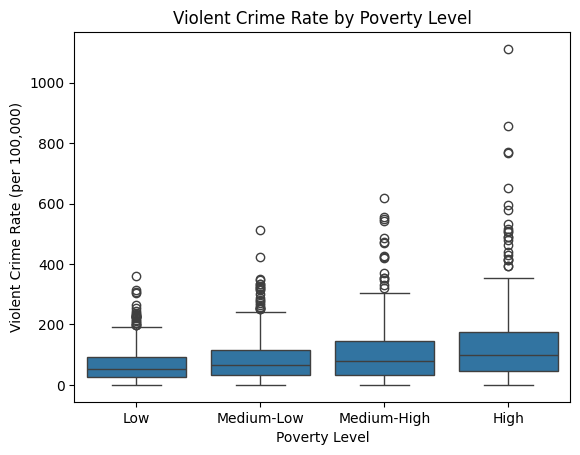

In [71]:
import seaborn as sns

sns.boxplot(
    data=df_valid,
    x="poverty_bin",
    y="violent_crime_rate_per_100k"
)
plt.xlabel("Poverty Level")
plt.ylabel("Violent Crime Rate (per 100,000)")
plt.title("Violent Crime Rate by Poverty Level")
plt.show()

In [72]:
df_valid["unemployment_bin"] = pd.qcut(
    df_valid["unemployment_pct"],
    4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

In [73]:
df_valid.groupby("unemployment_bin")["violent_crime_rate_per_100k"].mean()

unemployment_bin
Low             76.574472
Medium-Low      99.103013
Medium-High     98.597736
High           123.365207
Name: violent_crime_rate_per_100k, dtype: float64

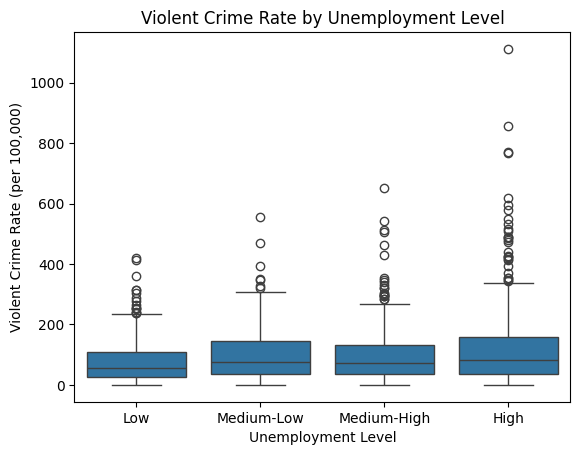

In [74]:
import seaborn as sns

sns.boxplot(
    data=df_valid,
    x="unemployment_bin",
    y="violent_crime_rate_per_100k"
)
plt.xlabel("Unemployment Level")
plt.ylabel("Violent Crime Rate (per 100,000)")
plt.title("Violent Crime Rate by Unemployment Level")
plt.show()

In [75]:
df_valid["education_bin"] = pd.qcut(
    df_valid["bachelors_or_higher_pct"],
    4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

In [76]:
df_valid.groupby("education_bin")["violent_crime_rate_per_100k"].mean()

education_bin
Low            135.339519
Medium-Low     104.828638
Medium-High     86.941396
High            66.646556
Name: violent_crime_rate_per_100k, dtype: float64

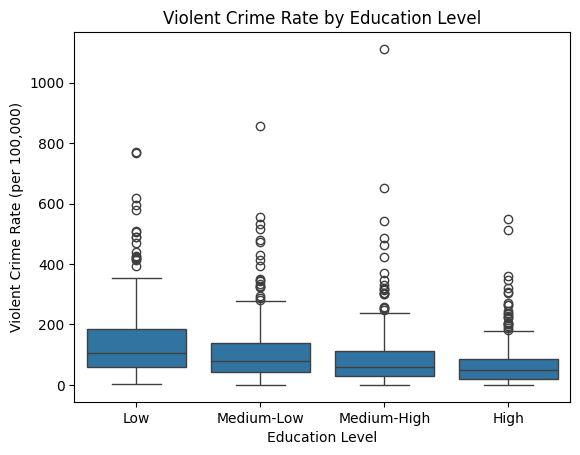

In [77]:
import seaborn as sns

sns.boxplot(
    data=df_valid,
    x="education_bin",
    y="violent_crime_rate_per_100k"
)
plt.xlabel("Education Level")
plt.ylabel("Violent Crime Rate (per 100,000)")
plt.title("Violent Crime Rate by Education Level")
plt.show()

In [78]:
df_valid.to_csv("capstone_data_with_crime_rate.csv", index=False)